In [1]:
# PC3236 Assignment 1
## Name : Vishesh Gauhar
## Student Number: A0228262W

In [255]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

### Question 1, Square Well

#### Defining the Square Well equations

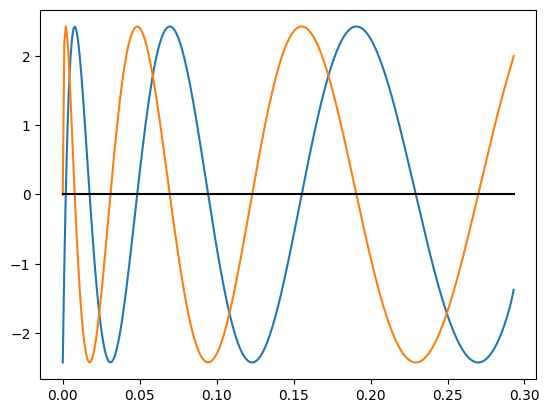

In [256]:
# For Plot Use
V0 = 8/27.211
a = 4/0.529
x = np.arange(0, V0, 0.001)
alpha = np.sqrt(2*10*x)
beta = np.sqrt(2*10*(V0-x))

evenplot = alpha * np.sin(alpha * a) - beta * np.cos(alpha * a)
oddplot =  alpha * np.cos(alpha * a) + beta * np.sin(alpha * a)


plt.plot(x, evenplot)
plt.plot(x, oddplot)
plt.plot(x, np.ones(x.shape[0])*0, color="black")
plt.show()

V0 = 8/27.211
a = 4/0.529

alpha = lambda x: np.sqrt(2*10*x)
beta = lambda x: np.sqrt(2*10*(V0-x))

evenState = lambda x: alpha(x) * np.tan(alpha(x) * a) - beta(x)
oddState = lambda x: alpha(x) *  (1 /(np.tan(alpha(x) * a))) + beta(x) 
# print(oddState(0))


    

In [257]:
def bisection(f, x1, x2): # x1 and x2 is the bracket initially
    TOL = 1 * np.exp(-10)
    Error = 1 * np.exp(10)
    Left ,Right = x1, x2
    fLeft, fRight = f(Left), f(Right)
    Errors = []
    n = 0
    print("Guesses (Middle)")
    while(Error > TOL):
        Middle = (Left + Right)/2

        print(Middle)
        fMiddle = f(Middle)
        # print(NewGuess)
        if (fLeft* fMiddle <= 0):
            Right = Middle
            fRight = fMiddle
        else:
            Left = Middle
            fLeft = fMiddle

        Error = abs((Right-Left)/Middle)
        Errors.append(Error)
        n = n + 1
    out = f"Root found at {Middle:.10f}"
    print(out)
    x = np.arange(0, n, step=1)
    y = Errors

    plt.plot(x, y)
    plt.xlabel("Iterations")
    plt.ylabel("Relative Error")
    plt.show()




### How do we choose initial brackets ? 
Since Tangent and Cotangent are periodic funcitons with known asymptotes, there is at most 1 root between 0 and the first asymptote for tangent, for cotangent since 0 is the first asymptote, we consider the second asymptote

The function  
$$
\tan\!\bigl(\alpha\,a\bigr)
$$
has its first asymptote at
$$
\alpha\,a = \frac{\pi}{2}.
$$
Solving for E using $$ \alpha\ = \sqrt{\frac{2ME}{\hbar}}\ $$,
$$
\sqrt{E} = \frac{\pi}{2a\sqrt{2M}}
$$

and therefore
$$
E = \left(\frac{\pi}{2a\sqrt{20}}\right)^2, M = 10 m_e = 10, \hbar = 1, a = 4 \AA = 4/0.529
$$
Similar for Cotangent 
$$
\cot\!\bigl(\alpha\,a\bigr) 
$$
that has its second (non 0) asymptote at

$$
\alpha\,a = \pi
$$

So similary:
$$
E = \left(\frac{\pi}{a\sqrt{20}}\right)^2.
$$

Even Root
Guesses (Middle)
0.0010788749864082997
0.0016183124796124496
0.0018880312262145246
0.002022890599515562
0.001955460912865043
0.0019217460695397839
0.0019386034912024135
0.0019470322020337283
0.001942817846618071
0.0019407106689102423
0.001939657080056328
0.001940183874483285
0.0019399204772698065
0.0019400521758765458
0.0019401180251799155
Root found at 0.0019401180


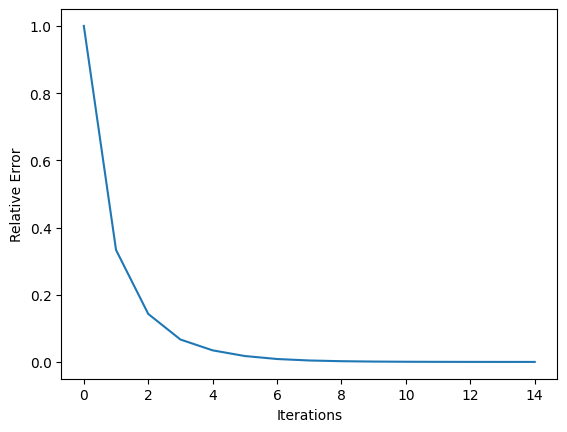

--------------
Odd Root
Guesses (Middle)
0.00431550097621001
0.006473250433738204
0.007552125162502301
0.008091562526884349
0.007821843844693324
0.007686984503597813
0.007754414174145569
0.0077881290094194465
0.007771271591782508
0.0077628428829640385
0.007758628528554804
0.0077565213513501865
0.007757574939952496
0.00775810173425365
0.007757838337103072
Root found at 0.0077578383


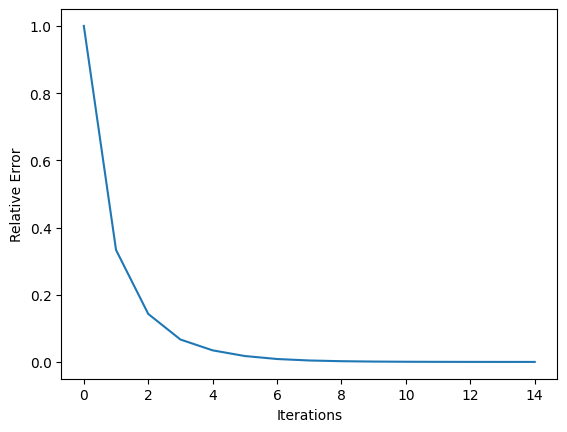

In [258]:

# evenAsymptote = np.pi/
evenAsymptote = (np.pi / (2 * a * np.sqrt(20)))**2
oddAsymptote = (np.pi / ( a * np.sqrt(20)))**2

# print(evenAsymptote)
# print(oddAsymptote)


print("Even Root") 
bisection(evenState, 0, evenAsymptote)
print("--------------")
print("Odd Root")
bisection(oddState, 0 + np.exp(-20), oddAsymptote) # 0 is an asymptote so choose a super small number close to 0 to start from instead


### Final Answer for Q.1
Lowest Even state at Energy = 0.0019401180 Hartree  
Lowest Odd state at Energy = 0.0077578383 Hartree  



### Question 2

Using the Newton Raphson method for simultaneous equations, as in lecture slides to solve for the constants in the equations, by substituting in the values given for $\theta$ and $R$

My initial guess vector for is $[C ,\, \epsilon,\, \alpha]$ = $[6800, 0.05, 0]$
Because we know that the simultaneous equations to solve for the constants look like
$$\frac{C}{1 + \epsilon sin(\theta + \alpha)} - R = 0$$
and $R$ is a big number close to 6800 so $C$ is also similary large, the guess for $\alpha$ can start at 0 but realistically can use any value as this is not likely to cause the gradients to go out of hand, that is more likely to happen with $C$ and $epsilon$, and for $\epsilon$ you have a small guess as well, much lesser than 1 because you expect that $1 + \epsilon \sin(\theta + \alpha)$ to be close to 1 as well since we want $\frac{C}{1 + \epsilon \sin(\theta + \alpha)} - R$ to be close to 0 to solve the equations


In [259]:
def feval(func ,x):
    out = []
    for i in range(func.size):
        out.append(func[i](x))
    return np.array(out).astype(float)

def simulroot(func , x):
    tol = np.exp(-3)
    root = [0,0,0]
    # eps = np.exp(-25)
    for i in range(100):
        jac, f0 = jacobian(func ,x)
        if np.sqrt(np.dot(f0,f0)/x.size) < tol:
            root = x
            return root
        # print(jac)
        dx = np.linalg.solve(jac, -f0)
        x = x + dx
        # print(np.sqrt(np.dot(dx,dx)/x.size))
        if np.sqrt(np.dot(dx,dx)/x.size) < tol:
            root = x
            return root
        # print(x)
    return root

f1 = lambda x: x[0]/(1 + x[1]*np.sin(-30/360 * (2*np.pi) + x[2])) - 6870
f2 = lambda x: x[0]/(1 + x[1]*np.sin(0/360 * (2*np.pi) + x[2])) - 6728
f3 = lambda x: x[0]/(1 + x[1]*np.sin(30/360 * (2*np.pi) + x[2])) - 6615

func = np.array([f1, f2 ,f3])
x = np.array([6800, 0.05 , 0]).astype(float)


def jacobian(func, x):
    h = np.exp(-4)
    n = x.size
    jac = np.zeros((n,n)).astype(float)
    f0 = feval(func , x)
    for i in range(n):
        temp = x[i]
        # print(temp)
        x[i] = temp + h
        f1 = feval(func,x)
        x[i] = temp 
        jac[:, i] = (f1 - f0)/h

    # print(jac)
    return jac, f0

# print(simulroot(func, x))
x = simulroot(func, x)

print(f'The following values were obtained for the constants C: {x[0]:.5f} Epsilon: {x[1]:.5f} Alpha: {x[2]*360/(2*np.pi):.5f} ')


The following values were obtained for the constants C: 6819.28147 Epsilon: 0.04060 Alpha: 19.52275 


In [260]:
theta_min = (np.pi/2 - x[2])/(2 * np.pi) * 360
fun = lambda y: x[0]/(1 + x[1]*np.sin(y/360 * (2*np.pi) + x[2]))
R_min = fun(theta_min)

Having found the constants we can easily determine theta that minimizes R. <br> 
Because $\sin(\theta + \alpha)$ is maximised when $\theta + \alpha = \frac{\pi}{2}$ ( $\sin(x)$ can at most be 1 at $x = \frac{\pi}{2}$). and when $\sin$ in s maximised the denominator is also maximised, and hence $R$ is minimized

Therefore $\theta_{minimize} = \frac{pi}{2} - \alpha$
 


In [261]:
print(f'The value of theta which minimizes R is {theta_min:.5f} degrees')
print(f'The minimum value of R is {R_min:.5f} km')

The value of theta which minimizes R is 70.47725 degrees
The minimum value of R is 6553.23097 km


### Final answer for Q.2

Final answer for $C,\,\epsilon,\,\alpha,\,\theta_{min},\,R_{min}$ <br>
$C = 6819.28147,\,\epsilon = 0.04060,\, \alpha = 19.52275 $ <br>
$\theta_{min} = 70.47725,\,R_{min} = 6553.23097$ km
